<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/09_ML_Dimension_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 차원 축소 (Dimension Reduction)

> 차원 축소 (Dimension Reduction)
- 수많은 특성(Feature)으로 이루어진 고차원 데이터를, 데이터의 핵심 정보와 의미를 최대한 보존하면서 더 적은 수의 차원(저차원)으로 변환하는 과정

- 많은 피처로 구성된 다차원 데이터 세트의 차원의 수를 줄인다,
  - Feature selection
    : 불필요한 특성은 제거하고, 데이터의 특징을 잘 나타내는 피처만 선택한다.
  - Feature extraction
    : 원래의 특성을 조합하여 데이터를 가장 잘 표현할 수 있는 중요한 성분들을 가진 새로운 특성을 추출한다.

- 알고리즘 설명
  - 주성분으로 정의한 초평면에 투영하여 데이터의 차원을 축소한다.
  - 이 초평면은 데이터의 분산을 가능한 최대로 보존한다.

In [2]:
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
dfX = pd.DataFrame(data=iris.data, columns = iris.feature_names)
dfY = pd.DataFrame(data=iris.target, columns = ['species'])

df=pd.concat([dfX,dfY],axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


- 피처와 레이블분리

In [4]:
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, :-1]
y = df.iloc[:,-1]

scaler = StandardScaler()
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


- 차원축소

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)
df = pd.DataFrame(data=X2, columns=['PC1', 'PC2'])
df.head()

,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


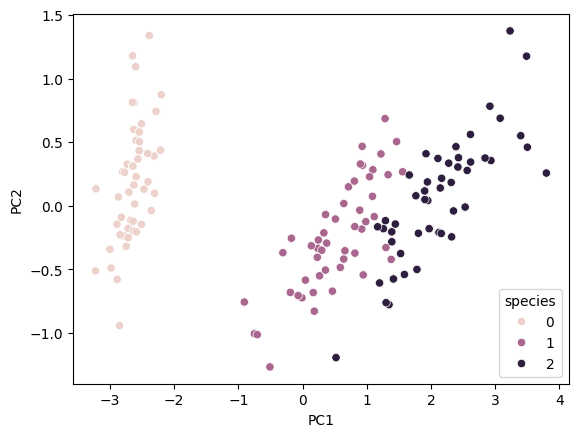

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='PC1', y='PC2', hue=y, data=df)
plt.show()

- 테스트데이터 분리

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [9]:
from sklearn.metrics import *

def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(accuracy_score(y_true, y_pred)))
  print('precision_score: {0:.4f}'.format(precision_score(y_true, y_pred, average='macro')))
  print('recall_score: {0:.4f}'.format(recall_score(y_true, y_pred, average='macro')))
y_pred = model.predict(X_test)
print_scores(y_test, y_pred)

accuracy_score: 1.0000
precision_score: 1.0000
recall_score: 1.0000


> **PCA(주성분 분석, Principal Component Analysis)**
- 데이터의 특성(변수)을 줄여 데이터셋의 크기를 압축하면서도 중요정보는 최대한 보존하는 대표적인 차원 축소(Dimension Reduction) 기법
---
- **원리**
  - PCA는 원본 데이터의 분산(데이터가 얼마나 널리 퍼져있는지)이 가장 큰 방향을 찾아 이를 새로운 축(주성분, Principal Component)으로 삼아 데이터를 투영

    - 분산 보존 : 첫 번째 주성분(PC1)은 데이터의 전체 분산을 가장 잘 설명하는 축
    - 직교성 : 두 번째 주성분(PC2)은 PC1과 직교이면서 분산을 두 번째로 많이 설명하는 축을 찾음
    - 차원 축소 : 이 과정을 반복하여 데이터셋의 총 분산을 만족할 만큼 설명하는 소수의 주성분만 남기고 나머지는 버림
---

- **차원 축소가 필요한 이유**
  - 차원의 저주 해결: 변수가 너무 많으면 데이터가 희소해지고 머신러닝 모델의 과적합 위험이 커짐. 변수를 줄여 이를 방지
  - 시각화 : 인간이 인식할 수 있는 최대 2-3차원으로 데이터를 축소하여 복잡한 데이터 구조를 한 눈에 파악할 수 있도록 함
  - 계산 효율성 : 불필요한 노이즈와 중복 정보를 제거하여 데이터 분석 및 모델 학습에 걸리는 시간을 크게 단축